Saved → trial_visualization.png

=== SANITY CHECK ===

Context task:
  obs shape        : (115, 7)
  fixation ends    : t=115
  stimulus ends    : t=115
  signed coherence : 3.061224
  stim ch1-4 mean (raw)  : [nan nan nan nan]
  stim ch1-4 mean (-0.5) : [nan nan nan nan]
  stim ch1-4 std         : [nan nan nan nan]
  NOTE: if coherence is 0.0, trial_info['coh'] returned None → bug in generator

Perceptual task:
  obs shape        : (115, 7)
  fixation ends    : t=115
  stimulus ends    : t=115
  signed coherence : 15.688775
  stim ch1-4 mean (raw)  : [nan nan nan nan]
  stim ch1-4 mean (-0.5) : [nan nan nan nan]
  stim ch1-4 std         : [nan nan nan nan]
  NOTE: if coherence is 0.0, trial_info['coh'] returned None → bug in generator


C:\Users\Jan\AppData\Local\Temp\ipykernel_1560\3275166621.py:214: RuntimeWarning: Mean of empty slice.
  print(f"  stim ch1-4 mean (raw)  : {stim_block.mean(axis=0).round(5)}")
c:\Users\Jan\miniconda3\envs\neuroai\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\Jan\AppData\Local\Temp\ipykernel_1560\3275166621.py:215: RuntimeWarning: Mean of empty slice.
  print(f"  stim ch1-4 mean (-0.5) : {(stim_block - 0.5).mean(axis=0).round(5)}")
c:\Users\Jan\miniconda3\envs\neuroai\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Jan\miniconda3\envs\neuroai\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Jan\miniconda3\envs\neuroai\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWar

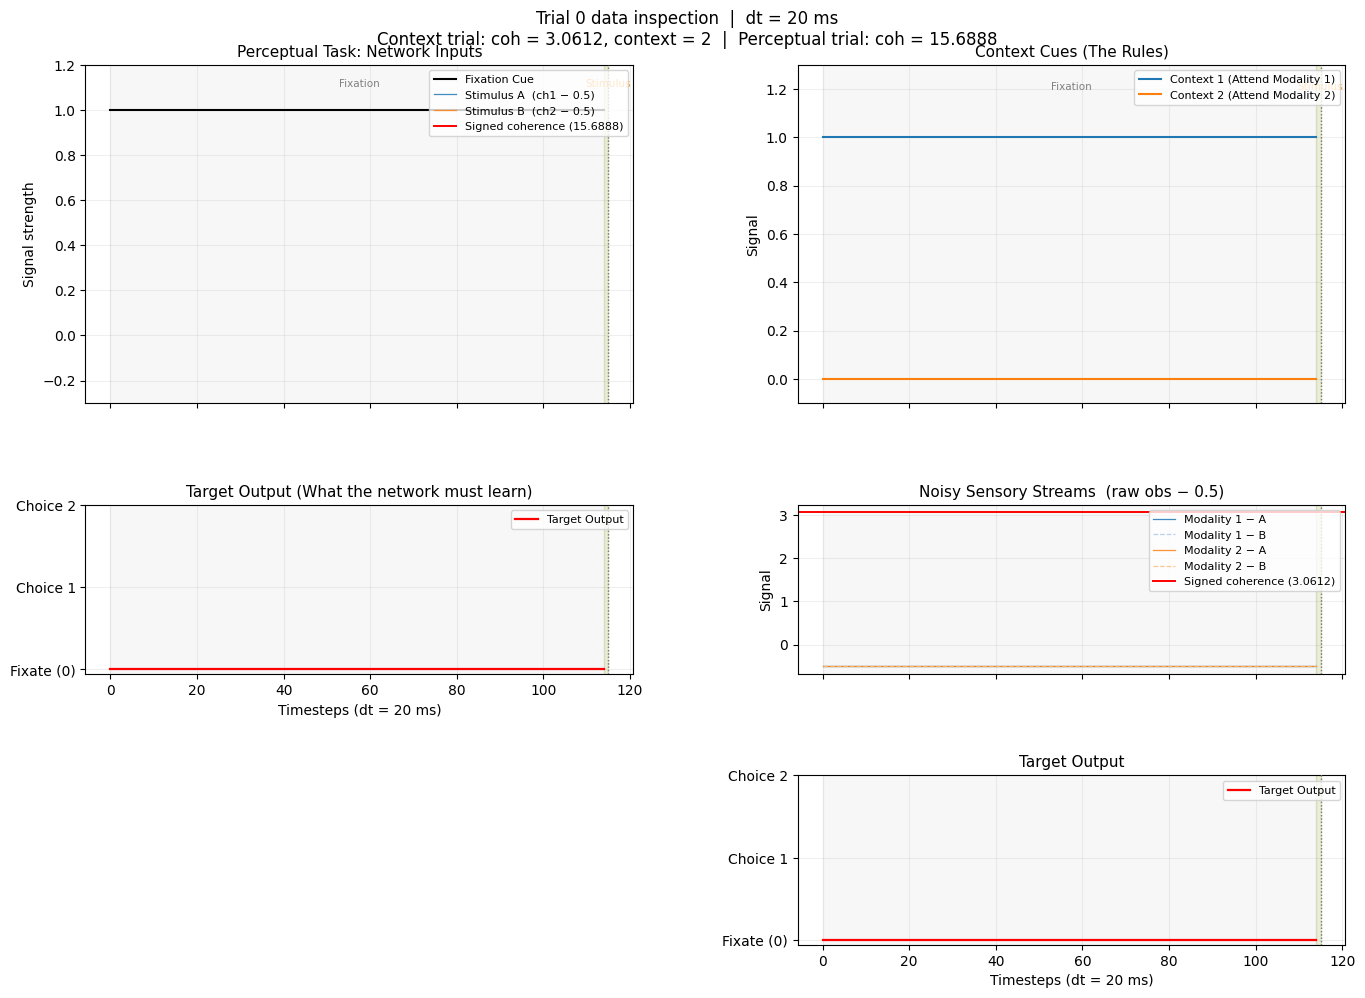

In [9]:
"""
visualize_trial.py
Reproduces the image-style trial visualization for one trial from both
the context and perceptual datasets.

Run from the project root:
    python src/analysis/visualize_trial.py

Outputs: trial_visualization.png
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── CONFIG ─────────────────────────────────────────────────────────────────
CONTEXT_NPZ    = "../data/mante_style/context/train.npz"
PERCEPTUAL_NPZ = "../data/mante_style/context/val.npz"
DT_MS          = 20          # change to match your dt setting
TRIAL_IDX      = 0           # which trial to inspect; change freely
OUTPUT_PATH    = "trial_visualization.png"
# ───────────────────────────────────────────────────────────────────────────


def load_trial(npz_path: str, idx: int):
    """Load one trial's arrays from a saved .npz file."""
    d = np.load(npz_path)
    return {
        "obs":     d["observations"][idx],      # (T, 7)
        "labels":  d["labels"][idx],            # (T,)
        "periods": d["trial_periods"][idx],     # (T,)
        "coh":     float(d["coherences"][idx]), # scalar
        "ctx":     int(d["contexts"][idx]),     # scalar
    }


def period_boundaries(periods: np.ndarray):
    """Return (fix_end, stim_end) timestep indices."""
    stim_ts = np.where(periods == 1)[0]
    dec_ts  = np.where(periods == 2)[0]
    fix_end  = stim_ts[0]  if len(stim_ts) else len(periods)
    stim_end = dec_ts[0]   if len(dec_ts)  else len(periods)
    return fix_end, stim_end


def shade_periods(ax, periods, fix_end, stim_end):
    """Light grey/orange/green background for fixation/stimulus/decision."""
    T = len(periods)
    ax.axvspan(0,        fix_end  - 1, alpha=0.06, color="grey",   zorder=0)
    ax.axvspan(fix_end,  stim_end - 1, alpha=0.08, color="orange", zorder=0)
    ax.axvspan(stim_end, T        - 1, alpha=0.08, color="green",  zorder=0)


def add_period_lines(ax, fix_end, stim_end):
    kw = dict(color="grey", linestyle=":", linewidth=0.9, zorder=5)
    ax.axvline(fix_end,  **kw)
    ax.axvline(stim_end, **kw)


# ── LOAD ───────────────────────────────────────────────────────────────────
ctx_trial  = load_trial(CONTEXT_NPZ,    TRIAL_IDX)
perc_trial = load_trial(PERCEPTUAL_NPZ, TRIAL_IDX)

# ── FIGURE LAYOUT (2 columns: perceptual left, context right) ───────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f"Trial {TRIAL_IDX} data inspection  |  dt = {DT_MS} ms\n"
    f"Context trial: coh = {ctx_trial['coh']:.4f}, context = {ctx_trial['ctx']}  |  "
    f"Perceptual trial: coh = {perc_trial['coh']:.4f}",
    fontsize=12, y=0.995
)

gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[2, 1, 1],
    hspace=0.45, wspace=0.30,
    left=0.07, right=0.97, top=0.94, bottom=0.06
)

ax_perc_stim = fig.add_subplot(gs[0, 0])
ax_perc_tgt  = fig.add_subplot(gs[1, 0], sharex=ax_perc_stim)
ax_ctx_cue   = fig.add_subplot(gs[0, 1])
ax_ctx_stim  = fig.add_subplot(gs[1, 1], sharex=ax_ctx_cue)
ax_ctx_tgt   = fig.add_subplot(gs[2, 1], sharex=ax_ctx_cue)

# Hide unused bottom-left cell
fig.add_subplot(gs[2, 0]).set_visible(False)

COLORS = {
    "fix":    "black",
    "m1a":    "#1f77b4",   # blue
    "m1b":    "#aec7e8",   # light blue
    "m2a":    "#ff7f0e",   # orange
    "m2b":    "#ffbb78",   # light orange
    "ctx1":   "#1f77b4",
    "ctx2":   "#ff7f0e",
    "coh":    "red",
    "target": "red",
}

# ── LEFT: PERCEPTUAL TASK ──────────────────────────────────────────────────
p  = perc_trial
ob = p["obs"]           # (T, 7) raw values from NeuroGym
T  = ob.shape[0]
t  = np.arange(T)
fix_end, stim_end = period_boundaries(p["periods"])

# NeuroGym encodes stimuli as (1 ± coh/100)/2  →  subtract 0.5 to centre
stim_raw = ob[:, 1:3] - 0.5   # perceptual: only ch1, ch2 carry signal

ax = ax_perc_stim
shade_periods(ax, p["periods"], fix_end, stim_end)
add_period_lines(ax, fix_end, stim_end)
ax.plot(t, ob[:, 0],      color=COLORS["fix"], linewidth=1.5, label="Fixation Cue")
ax.plot(t, stim_raw[:, 0], color=COLORS["m1a"], linewidth=0.9, alpha=0.85, label="Stimulus A  (ch1 − 0.5)")
ax.plot(t, stim_raw[:, 1], color=COLORS["m2a"], linewidth=0.9, alpha=0.85, label="Stimulus B  (ch2 − 0.5)")
ax.axhline(p["coh"], color=COLORS["coh"], linewidth=1.4, linestyle="-",
           label=f"Signed coherence ({p['coh']:.4f})")
ax.set_title("Perceptual Task: Network Inputs", fontsize=11)
ax.set_ylabel("Signal strength")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)
ax.set_ylim(-0.3, 1.2)
plt.setp(ax_perc_stim.get_xticklabels(), visible=False)

ax = ax_perc_tgt
shade_periods(ax, p["periods"], fix_end, stim_end)
add_period_lines(ax, fix_end, stim_end)
ax.step(t, p["labels"], where="post", color=COLORS["target"], linewidth=1.6, label="Target Output")
ax.set_title("Target Output (What the network must learn)", fontsize=11)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Fixate (0)", "Choice 1", "Choice 2"])
ax.set_xlabel(f"Timesteps (dt = {DT_MS} ms)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)

# ── RIGHT: CONTEXT TASK ────────────────────────────────────────────────────
p  = ctx_trial
ob = p["obs"]
T  = ob.shape[0]
t  = np.arange(T)
fix_end, stim_end = period_boundaries(p["periods"])

# Context cues: ch5, ch6 (already 0/1 binary)
cue1 = ob[:, 5]
cue2 = ob[:, 6]

# Stimulus channels: subtract 0.5 to centre
stim = ob[:, 1:5] - 0.5   # (T, 4): [mod1A, mod1B, mod2A, mod2B]

ax = ax_ctx_cue
shade_periods(ax, p["periods"], fix_end, stim_end)
add_period_lines(ax, fix_end, stim_end)
ax.plot(t, cue1, color=COLORS["ctx1"], linewidth=1.5, label="Context 1 (Attend Modality 1)")
ax.plot(t, cue2, color=COLORS["ctx2"], linewidth=1.5, label="Context 2 (Attend Modality 2)")
ax.set_title("Context Cues (The Rules)", fontsize=11)
ax.set_ylabel("Signal")
ax.set_ylim(-0.1, 1.3)
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)
plt.setp(ax_ctx_cue.get_xticklabels(), visible=False)

ax = ax_ctx_stim
shade_periods(ax, p["periods"], fix_end, stim_end)
add_period_lines(ax, fix_end, stim_end)
ax.plot(t, stim[:, 0], color=COLORS["m1a"],  linewidth=0.9, alpha=0.85, label="Modality 1 − A")
ax.plot(t, stim[:, 1], color=COLORS["m1b"],  linewidth=0.9, alpha=0.85, label="Modality 1 − B", linestyle="--")
ax.plot(t, stim[:, 2], color=COLORS["m2a"],  linewidth=0.9, alpha=0.85, label="Modality 2 − A")
ax.plot(t, stim[:, 3], color=COLORS["m2b"],  linewidth=0.9, alpha=0.85, label="Modality 2 − B", linestyle="--")
ax.axhline(p["coh"], color=COLORS["coh"], linewidth=1.4, linestyle="-",
           label=f"Signed coherence ({p['coh']:.4f})")
ax.set_title("Noisy Sensory Streams  (raw obs − 0.5)", fontsize=11)
ax.set_ylabel("Signal")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)
plt.setp(ax_ctx_stim.get_xticklabels(), visible=False)

ax = ax_ctx_tgt
shade_periods(ax, p["periods"], fix_end, stim_end)
add_period_lines(ax, fix_end, stim_end)
ax.step(t, p["labels"], where="post", color=COLORS["target"], linewidth=1.6, label="Target Output")
ax.set_title("Target Output", fontsize=11)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Fixate (0)", "Choice 1", "Choice 2"])
ax.set_xlabel(f"Timesteps (dt = {DT_MS} ms)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.2)

# ── Period legend annotation ───────────────────────────────────────────────
for ax_row in [ax_perc_stim, ax_ctx_cue]:
    ax_row.text(fix_end / 2,                ax_row.get_ylim()[1] * 0.92,
                "Fixation", ha="center", fontsize=7.5, color="grey")
    ax_row.text((fix_end + stim_end) / 2,   ax_row.get_ylim()[1] * 0.92,
                "Stimulus", ha="center", fontsize=7.5, color="darkorange")
    if stim_end < T:
        ax_row.text((stim_end + T) / 2,     ax_row.get_ylim()[1] * 0.92,
                    "Decision", ha="center", fontsize=7.5, color="darkgreen")

# plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
print(f"Saved → {OUTPUT_PATH}")

# ── QUICK SANITY PRINT ─────────────────────────────────────────────────────
print("\n=== SANITY CHECK ===")
for name, trial in [("Context", ctx_trial), ("Perceptual", perc_trial)]:
    ob = trial["obs"]
    fix_end, stim_end = period_boundaries(trial["periods"])
    stim_block = ob[fix_end:stim_end, 1:5]
    print(f"\n{name} task:")
    print(f"  obs shape        : {ob.shape}")
    print(f"  fixation ends    : t={fix_end}")
    print(f"  stimulus ends    : t={stim_end}")
    print(f"  signed coherence : {trial['coh']:.6f}")
    print(f"  stim ch1-4 mean (raw)  : {stim_block.mean(axis=0).round(5)}")
    print(f"  stim ch1-4 mean (-0.5) : {(stim_block - 0.5).mean(axis=0).round(5)}")
    print(f"  stim ch1-4 std         : {stim_block.std(axis=0).round(5)}")
    print(f"  NOTE: if coherence is 0.0, trial_info['coh'] returned None → bug in generator")